# LFM Instance Segmentation Example Workflow
This notebook trains a Graha/Lunar-FM Mask R-CNN instance segmentation model for crater detection. It loads a split crater instance dataset, builds the Graha object-detection datamodule and TerraTorch task, runs fine-tuning, writes checkpoints, and creates validation prediction plots.

## Purpose of this notebook
Use this notebook as the active interactive Graha instance-segmentation training workflow. The values in the **User Configuration** section mirror the most commonly changed command-line options; lower-level options stay on the centralized experiment-config defaults unless they are explicitly promoted into that section.

**Note**: dataset-specific image/label matching, band selection, normalization modality, and Graha input modality are controlled by `DATA_DICT` in the **User Configuration** section. See the repository README for dataset-specific examples.

### Setup
This notebook requires you to select the 'lfm_kernel' kernel from the top right of the webpage (this is the standard kernel). 

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import sys

from functools import partialmethod
from glob import glob
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
from lightning.pytorch import seed_everything
from tqdm import tqdm

tqdm.__init__ = partialmethod(tqdm.__init__, disable=False)

In [2]:
repo_root = Path.cwd().parent
repo_root_str = str(repo_root).replace('/panfs/ccds02/nobackup', '/explore/nobackup')
repo_root = Path(repo_root_str)
NOTEBOOK_DIR = repo_root / "notebooks"

if not (repo_root / "lfm").exists():
    raise FileNotFoundError(
        "Cannot find the lfm/ directory. Run this notebook "
        "from the repository's top-level notebooks/ directory."
    )

sys.path.insert(0, str(repo_root))

from lfm.all_models.all_tasks.utils import (
  create_timestamped_output_dir,
  plot_instance_cache_predictions,
  save_graha_instance_prediction_cache,
)
from lfm.all_models.inst_seg import build_graha_notebook_configs
from lfm.full_model.inst_seg import instance_graha_components

print("Successfully imported LFM modules")

Successfully imported LFM modules


## User Configuration

These are the values a notebook user is expected to edit for a normal Graha semantic-segmentation run.

### Paths

- `BASE_OUTPUT_DIR`: parent directory for timestamped notebook outputs. Checkpoints, config files, prediction caches, and plots are written under a new timestamped subdirectory.

- `PRETRAIN_DIR`: Graha/Lunar-FM pretraining directory. It must contain `checkpoints/checkpoint_weights_final.pt`, `full_config.yaml`, and `modality_info.yaml`.

- `LIGHTNING_CHECKPOINT`: optional Graha Lightning checkpoint to resume from. Leave as `None` for a fresh fine-tune.

### Data Selection

To switch datasets, replace `DATA_DICT` with the matching dictionary from the README, under **"Dataset Specifications"**. If you'd like to use your own dataset (not found in the Dataset Specifications section of the README), reference `docs/dataset_contribution.md`.

**For more info on the WAC + Static dataset, see docs/wac_static_bands.md**.

#### Data dictionary

- `DATA_DICT`: dataset-level dictionary that controls the data-specific parts of training. It defines the dataset directory, dataset modality, selected modalities, optional file matching, band selection, NoData policy values, and optional Graha input mode override.

- `DATA_DICT["dataset_name"]`: dataset name for readability. Has no effect on model/dataset functionality.

- `DATA_DICT["data_dir"]`: path to dataset root. This root should contain `train`, `val`, and `test` split folders.

- `DATA_DICT["dataset_modality"]`: stored chip layout. Supported values include `"wac"`, `"wac_static"`, `"nac"`, and `"nac_dtm"`; this controls default normalization behavior.

- `DATA_DICT["selected_modalities"]`: frontend modalities to load from the stored chips. To remove a modality, delete it from this list and remove its `band_filters` entry.

    - `["vis", "uv", "static"]` -> `["vis", "uv"]`

- `DATA_DICT["graha_input_modality_mode"]`: optional explicit Graha mode for the selected modalities. Current useful values are `"vis"`, `"uv"`, `"static"`, `"vis-uv"`, `"vis-uv-static"`, `"nac"`, `"dtm"`, and `"nac-dtm"`. If omitted, it is inferred from `selected_modalities`.

- `DATA_DICT["band_filters"]`: modality-local band selection. For WAC, `"vis": [0, 1, 2, 3, 4]` and `"uv": [0, 1]` selects all 7 stored WAC channels. For NAC PHO or DTM, use `[0]` because each modality is stored as a single band. Do not use empty lists to remove a modality; remove that modality from `selected_modalities` and omit its band filter.

- `DATA_DICT["excluded_nodata_values"]`: only used for datasets containing static data. Known NoData values to ignore in model ingestion/loss behavior so sentinel values do not become learnable image structure.

#### Sample selection

- `MAX_TRAIN_SAMPLES`, `MAX_VAL_SAMPLES`, `MAX_TEST_SAMPLES`: optional split caps for quick experiments. Set any of these to `None` to use the full split. If fewer samples are found than the max amount, the actual sample count will be used.

### Training Parameters

- `BATCH_SIZE`: Graha training batch size. Typically a multiple of 8 to aid parallelization in GPU architecture.

- `MAX_EPOCHS`: number of fine-tuning epochs. The default is currently 1 for demonstration purposes, but better science runs typically use a larger value.

- `GRAHA_BACKBONE_LR`, `GRAHA_HEAD_LR`, `GRAHA_LAYER_DECAY`, `GRAHA_WEIGHT_DECAY`, `GRAHA_WARMUP_STEPS`: Graha optimizer schedule parameters.

- `GRAHA_FREEZE_BACKBONE`: whether to keep Graha backbone frozen (aka whether to omit Graha model weights from training, only training the decoder). 


### Defaults Kept In Code

The notebook leaves these centralized defaults unchanged unless you intentionally add overrides to the config cell. File suffixes are inferred automatically from common names such as `_input_nac_chip`, `_input_wac_chip`, `_input_wac_static_chip`, `_label`, `_mask`, `_mask_orig`, and `_img`; add explicit `image_suffix` or `label_suffix` only for unusual datasets. Backend Graha/TerraTorch modalities are inferred from `selected_modalities` (`pho` maps to `nac`). Multi-modality Graha features use concat merging by default. Normalization source defaults to `"pretrain"`. A seed of 42 is used for random number generators, to ensure reproducibility.

In [3]:
BASE_OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "instance_seg_finetuning"  # Base output directory for finetune plots etc.
PRETRAIN_DIR = "/explore/nobackup/projects/lfm/ibm_model_pretrain_dir_v2"  # Where to load Graha configuration/checkpoint from
LIGHTNING_CHECKPOINT = None  # Fine-tuned checkpoint to resume from (fresh starts should use 'None')

# Data dictionary; see README under "Dataset Specifications" for examples.
DATA_DICT = {
    "dataset_name": "wac_static_craters",  # Human-readable dataset label; does not change model behavior.
    "data_dir": "/explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/chip_dataset/20261008T094736_695696",  # Dataset root containing train/val/test split folders.
    "dataset_modality": "wac_static",  # Stored chip layout: 5 VIS + 2 UV + 63 static bands.
    "selected_modalities": ["vis", "uv", "static"],  # Frontend modalities to feed the model; delete entries to omit them.
    "band_filters": {  # Modality-local band indices to keep from each selected modality.
        "vis": [0, 1, 2, 3, 4],  # Keep all 5 VIS bands.
        "uv": [0, 1],  # Keep both UV bands.
        "static": [  # Keep all 63 static bands; remove individual indices here for ablation tests.
            0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
            10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
            20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
            30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
            40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
            50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
            60, 61, 62,
        ],
    },
    "excluded_nodata_values": [  # Known NoData sentinels to ignore when building model masks.
        -32768.0,  # Shared Lunar FM datacube NoData value.
        -3.4028226550889045e38,  # Static-source Float32 sentinel variant.
        -3.4028230607370965e38,  # Static-source Float32 sentinel variant.
        -3.4028234663852886e38,  # Static-source Float32 sentinel variant.
    ],
}

# Upper limit for sample counts in train/val/test datasets; if less samples are found, that amount will be used instead
MAX_TRAIN_SAMPLES = 500
MAX_VAL_SAMPLES = 500
MAX_TEST_SAMPLES = 500

BATCH_SIZE = 8  # Number of inputs fed into the model per iteration; often a multiple of 8 for parallelization purposes
MAX_EPOCHS = 10  # Maximum number of epochs, default to 1 for demo purposes. Finetuning typically uses 50-100 epochs, but sometimes less can work.

GRAHA_BACKBONE_LR = 5.0e-5  # Learning rate for Graha FM backbone (lower than head typically)
GRAHA_HEAD_LR = 2.0e-4  # Learning rate for task decoder (higher than backbone typically)
GRAHA_LAYER_DECAY = 0.75  # Decays learning rate further toward the backbone; allows for more gentle tuning of Graha backbone weights
GRAHA_WEIGHT_DECAY = 0.05  # Penalizes large model weights during training, helping model generalize to non-training data
GRAHA_WARMUP_STEPS = 500  # Number of optimizer steps before LR scheduler warmup ends
GRAHA_FREEZE_BACKBONE = False  # Whether to freeze Graha backbone (can be a useful tool during training to change to True/False)

The configuration cell above mirrors the active Graha instance-segmentation training settings. Values not listed there use the centralized defaults documented in the previous markdown cell.


In [4]:
OUTPUT_DIR = create_timestamped_output_dir(BASE_OUTPUT_DIR)

notebook_configs = build_graha_notebook_configs(
    output_dir=OUTPUT_DIR,
    base_output_dir=OUTPUT_DIR,
    graha_pretrain_dir=PRETRAIN_DIR,
    graha_lightning_checkpoint=LIGHTNING_CHECKPOINT,
    data_dict=DATA_DICT,
    max_epochs=MAX_EPOCHS,
    graha_batch_size=BATCH_SIZE,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_val_samples=MAX_VAL_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
    graha_backbone_lr=GRAHA_BACKBONE_LR,
    graha_head_lr=GRAHA_HEAD_LR,
    graha_layer_decay=GRAHA_LAYER_DECAY,
    graha_weight_decay=GRAHA_WEIGHT_DECAY,
    graha_warmup_steps=GRAHA_WARMUP_STEPS,
    graha_freeze_backbone=GRAHA_FREEZE_BACKBONE,
)

config = notebook_configs.experiment_config
graha_config = notebook_configs.graha_config
deps = notebook_configs.dependencies

seed_everything(config.seed)
instance_graha_components.save_config(graha_config, OUTPUT_DIR)

print("Config created successfully")
print(f"Data dir: {config.data_root}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Graha modality mode: {config.graha_input_modality_mode}")
print(f"Normalization modality: {config.normalization_modality}")

Using output subdir: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/instance_seg_finetuning/date_2026_10_08-time_09_53_42
PROJ_DATA = /usr/share/proj
GDAL_DATA = /usr/share/gdal


W1008 09:54:04.928000 4102834 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1008 09:54:05.158000 4102834 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[rank: 0] Seed set to 42


Config created successfully
Data dir: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/chip_dataset/20261008T094736_695696
Output dir: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/instance_seg_finetuning/date_2026_10_08-time_09_53_42
Graha modality mode: vis-uv-static
Normalization modality: vis_uv_static


Set PyTorch device to CUDA (GPU-accelerated) if possible

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Output Directory

The timestamped output directory was created while building the config. It contains the saved config, checkpoints, prediction caches, and plots for this run.

In [6]:
print(f"Notebook output directory: {OUTPUT_DIR}")

Notebook output directory: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/instance_seg_finetuning/date_2026_10_08-time_09_53_42


## Create datamodule

1. Load pretraining stats from .yaml file
2. Create datamodule using pretraining stats and other config options

In [7]:
# STEP 1: pretraining stats
print("\nSTEP 1: Loading pretraining stats...")
print("="*60)

datamodule_cls = deps["GrahaObjectDetectionInstanceDataModule"]
means, stds = instance_graha_components.get_normalization_stats(
    graha_config,
    datamodule_cls,
)

print("Done.")


STEP 1: Loading pretraining stats...
TerraMind WAC+static pretraining modality info: /explore/nobackup/projects/lfm/ibm_model_pretrain_dir_v2/modality_info.yaml
TerraMind WAC+static pretraining mean: [0.0262588825351396, 0.0355034864633048, 0.0379165676944608, 0.0398220978887433, 0.0425382088988623, 0.0176056219925766, 0.0208237419578931, 0.47907027086137227, 0.4437987016160499, 0.27197882092433007, 0.041988115587187666, 0.04905481532001399, 0.05764959889924966, 0.08172100831473417, 0.08814712824526566, 0.09546992658678505, 0.10316492463251584, 0.044446158407449254, 2.7954877641347817, 3.6046559278951515, 0.0701859629495605, 0.004344066930877969, 234.1070762210875, 221.06450937692844, 207.97370302306933, 226.75159127435535, 243.15052669426663, 234.75795316214877, 228.02890449917476, 233.54229049883546, 234.80803938152005, 231.88343564665104, 226.3692190847741, 217.63260581216284, 204.43991169902134, 175.65343939215762, 132.42259194369296, 142.6642293353681, 161.07358777588686, 173.903

In [8]:
print("\nSTEP 2: Creating datamodule and inspecting one training batch...")
print("=" * 60)

graha_datamodule = instance_graha_components.create_datamodule(
    graha_config,
    datamodule_cls,
    means,
    stds,
)
graha_sample_batch = instance_graha_components.inspect_batch(graha_datamodule)

print("Done.")


STEP 2: Creating datamodule and inspecting one training batch...
[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[train] Found 91 matched image-label pairs
[train] Dataset configured for 70 channel(s)
[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[val] Found 12 matched image-label pairs
[val] Dataset configured for 70 channel(s)
batch keys: dict_keys(['image', 'boxes', 'labels', 'masks', 'filename', 'mask', 'crater_boxes', 'num_craters'])
image: (8, 70, 256, 256) torch.float

## Create Terratorch Task Object, Model

In [9]:
task_cls = instance_graha_components.make_downstream_object_detection_task_class(
    deps["LunarObjectDetectionTask"]
)

graha_task = instance_graha_components.create_task(
    graha_config,
    task_cls,
    graha_sample_batch,
)
instance_graha_components.run_loss_smoke(graha_task, graha_sample_batch)

Input channels registered for model: 70
Graha input modality mode: vis-uv-static
Graha backend modalities: ['vis', 'uv', 'static']
Backbone modalities: ['vis', 'uv', 'static']
Backbone merge method: concat
Freeze backbone: False
LunarBackbone: using modality_info.yaml from '/explore/nobackup/projects/lfm/ibm_model_pretrain_dir_v2/modality_info.yaml' (21 modalities: ['aspect', 'aspect_3m', 'dtm', 'dtm_3m', 'metadata', 'nac', 'slope', 'slope_3m', 'static', 'static_maps', 'tok_aspect', 'tok_aspect_3m', 'tok_dtm', 'tok_dtm_3m', 'tok_nac', 'tok_slope', 'tok_slope_3m', 'tok_uv', 'tok_vis', 'uv', 'vis'])


/usr/local/lib/python3.12/dist-packages/terratorch/tasks/object_detection_task.py:85: UserWarning: The Object Detection Task has to be considered experimental. This is less mature than the other tasks and being further improved.
  warnings.warn(


Auto-detected num_register_tokens=0 from checkpoint
encoder_embeddings.static.mod_emb
encoder_embeddings.static.pos_emb
encoder_embeddings.static.proj.weight
encoder_embeddings.aspect.mod_emb
encoder_embeddings.aspect.pos_emb
encoder_embeddings.aspect.proj.weight
encoder_embeddings.aspect_3m.mod_emb
encoder_embeddings.aspect_3m.pos_emb
encoder_embeddings.aspect_3m.proj.weight
encoder_embeddings.dtm.mod_emb
encoder_embeddings.dtm.pos_emb
encoder_embeddings.dtm.proj.weight
encoder_embeddings.dtm_3m.mod_emb
encoder_embeddings.dtm_3m.pos_emb
encoder_embeddings.dtm_3m.proj.weight
encoder_embeddings.metadata.mod_emb
encoder_embeddings.metadata.pos_emb
encoder_embeddings.metadata.token_emb.weight
encoder_embeddings.nac.mod_emb
encoder_embeddings.nac.pos_emb
encoder_embeddings.nac.proj.weight
encoder_embeddings.slope.mod_emb
encoder_embeddings.slope.pos_emb
encoder_embeddings.slope.proj.weight
encoder_embeddings.slope_3m.mod_emb
encoder_embeddings.slope_3m.pos_emb
encoder_embeddings.slope_3m.p

## Run Training

In [10]:
trainer = instance_graha_components.create_trainer(graha_config, OUTPUT_DIR)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
print("\n" + "=" * 60)
print("Starting training.")
print("=" * 60)

ckpt_path = (
    str(graha_config.lightning_checkpoint)
    if graha_config.lightning_checkpoint is not None
    else None
)
trainer.fit(
    graha_task,
    datamodule=graha_datamodule,
    ckpt_path=ckpt_path,
)

print("Finished training.")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.



Starting training.
[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[train] Found 91 matched image-label pairs
[train] Dataset configured for 70 channel(s)
[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[val] Found 12 matched image-label pairs
[val] Dataset configured for 70 channel(s)
[LunarObjectDetectionTask] 17 param groups, 248.6M trainable params. layer_decay=0.75 backbone_lr=5e-05 head_lr=0.0002
  backbone_layer_0_nd              lr=1.19e-06 wd=0.00e+00 n=22,272
  backb

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ObjectDetectionModel │  248 M │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 248 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 248 M                                                                                                
Total estimated model params size (MB): 994.337                                                                    
Modules in train mode: 547                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


Output()

[val epoch 0] preds=1044 across 12 imgs (preds/img mean=87.0 gt/img mean=1.3) | score max=0.681 p50=0.524 p90=0.563
p99=0.600 | n(>0.1)=1044 n(>0.3)=1044 n(>0.5)=1044

`Trainer.fit` stopped: `max_epochs=10` reached.


Finished training.


## Create And Display Validation Visualizations

Using the saved checkpoint, this section inferences/predicts on the reserved validation dataset and displays a visualization for review

In [12]:
prediction_cache = save_graha_instance_prediction_cache(
    task=graha_task,
    datamodule=graha_datamodule,
    output_dir=OUTPUT_DIR,
    model_name="graha",
    split=config.prediction_split,
    n_samples=config.prediction_n_samples,
    score_threshold=config.prediction_score_threshold,
)

prediction_plot = plot_instance_cache_predictions(
    prediction_cache,
    OUTPUT_DIR / "plots" / "single_model" / "graha_model",
    model_name="graha",
    n_samples=config.prediction_n_samples,
    filename=f"{config.prediction_split}_instance_predictions.png",
)
print(f"Saved prediction plot: {prediction_plot}")

[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[train] Found 91 matched image-label pairs
[train] Dataset configured for 70 channel(s)
[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[val] Found 12 matched image-label pairs
[val] Dataset configured for 70 channel(s)
Saved 5 graha instance prediction cache file(s) to /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/instance_seg_finetuning/date_2026_10_08-time_09_53_42/prediction_cache/graha/val
Saved i

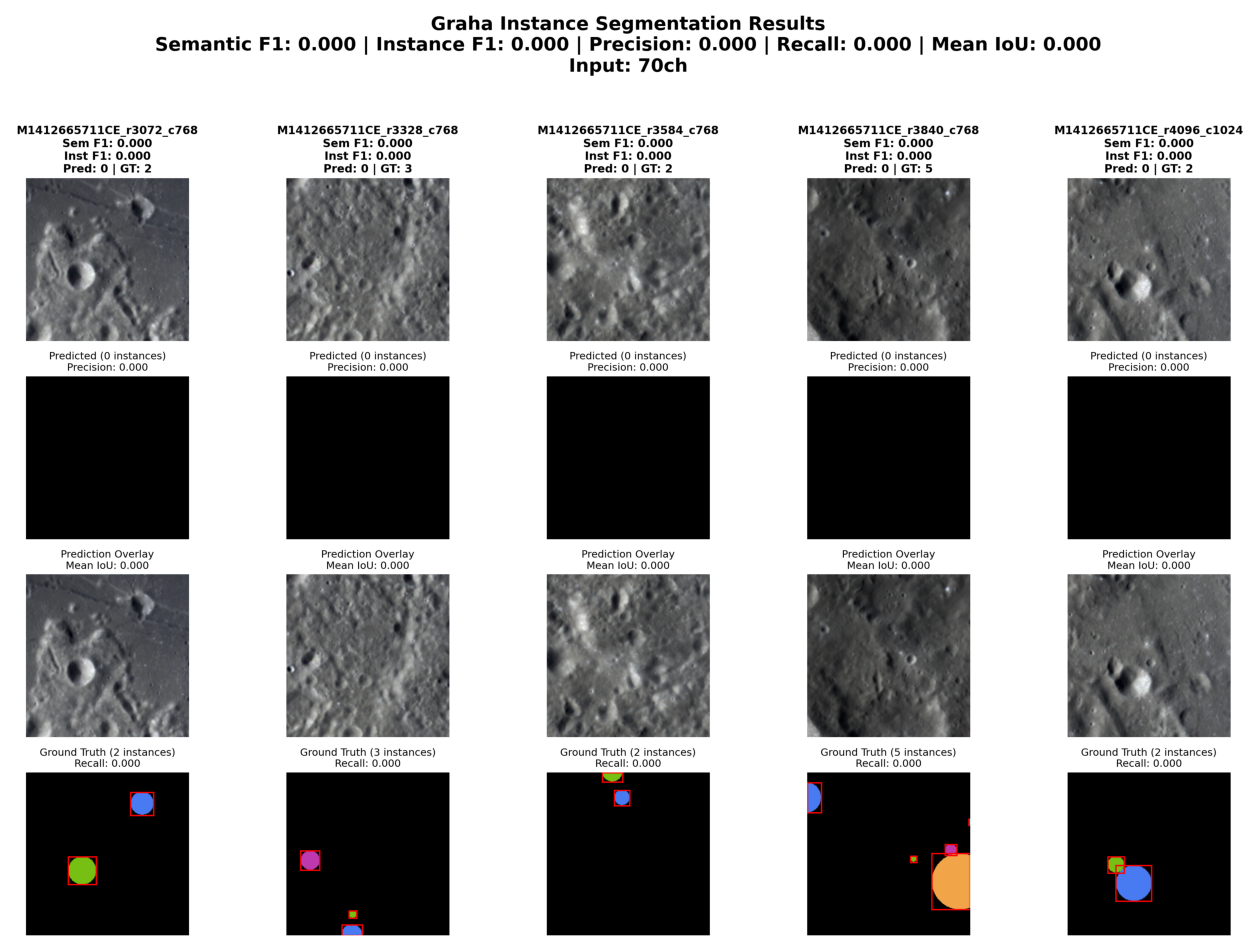

In [13]:
img = mpimg.imread(prediction_plot)
plt.figure(figsize=(16, 14))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
del graha_task, graha_datamodule, trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()